# 기초 데이터 시각화 (pandas 없이)

이 노트북은 `scikit-learn`으로 Iris 데이터셋을 불러오고, NumPy로 간단한 통계를 계산한 뒤, `matplotlib`로 기본 시각화를 수행하는 과정을 다룸.  
이번 실습에서는 히스토그램, 산점도, 상자수염그림을 직접 그려봄.

## 1. 라이브러리 불러오기와 데이터셋 로드

이 단계에서 수행할 내용은 다음과 같음.

1. `sklearn.datasets`에서 Iris 데이터셋을 불러옴.
2. 입력 특성(`X`)과 레이블(`y`)을 나눔.
3. 데이터의 shape와 feature 이름을 확인함.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Shape: (150, 4
f1 = X[:, 0] # 넘파이 배열 슬라이싱 [행, 열] 데이터 150 개, 열(feature) 4 개
f2 = X[:, 1]
print(X)
print(f1)
y = iris.target  # Shape: (150,)
feature_names = iris.feature_names # x의 열하나. column 의 형태, 즉 꽃받침 길이, 꽃받침 너비, 꽃잎 길이, 꽃입 너비
target_names = iris.target_names # label
print(y)
print("Data shape (X):", X.shape)
print("Labels shape (y):", y.shape)
print("Feature names:", feature_names)
print("Target names:", target_names)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

## 2. 기초 통계

NumPy를 사용하면 각 feature의 평균과 표준편차를 빠르게 확인할 수 있음.  
또한 각 품종별 샘플 수가 몇 개인지도 함께 확인할 수 있음.

In [3]:
# 각 feature의 평균과 표준편차 계산함
# TODO 1: 각 열(feature) 기준 평균 계산함.
# 힌트: NumPy의 reduction function 사용함. 결과 shape는 (4,)가 되어야 함.
# 해결법, np.mean() 을 사용, axis 에 대한 평균 사용하기
mean_values = X.mean(axis=0)
# TODO 2: 각 열(feature) 기준 표준편차 계산함.
# 힌트: 평균 계산과 같은 방식으로 feature 축 유지함.
std_values = X.std(axis=0)

print("Feature means:", mean_values)
print("Feature std dev:", std_values)

# 각 품종별 샘플 수 계산함
unique_species, counts = np.unique(y, return_counts=True) # 중복제거 + 각 값이 몇번 나왔는지
print("\nSpecies distribution:")
print("counts:", counts)
print("unique_species:", unique_species)
for species_id, count in zip(unique_species, counts): # zip 은 같은 인덱스 끼리 묶는다.
    print(f"{target_names[species_id]}: {count} samples")

Feature means: [5.84333333 3.05733333 3.758      1.19933333]
Feature std dev: [0.82530129 0.43441097 1.75940407 0.75969263]

Species distribution:
counts: [50 50 50]
unique_species: [0 1 2]
setosa: 50 samples
versicolor: 50 samples
virginica: 50 samples


## 3. 데이터 시각화

다음 세 가지 시각화를 만들어봄.

1. 하나의 feature에 대한 **히스토그램**
2. 두 feature를 비교하는 **산점도** (품종별 색상 구분)
3. 품종별 한 feature 분포를 비교하는 **상자수염그림**

### 3.1 히스토그램

**sepal length** (feature index 0)의 분포를 그려봄.

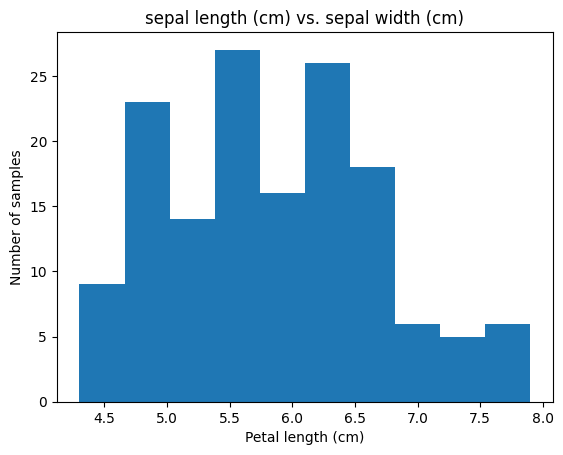

In [5]:
lengths = np.array(f1)

plt.title('sepal length (cm) vs. sepal width (cm)')
plt.hist(lengths, bins = 10)
plt.xlabel("Petal length (cm)")
plt.ylabel("Number of samples")
plt.show()

### 3.2 산점도

**sepal length** (feature 0)와 **sepal width** (feature 1)를 비교하는 산점도를 그려봄.  
점의 색상은 품종에 따라 다르게 표시함.

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False]
X0:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  

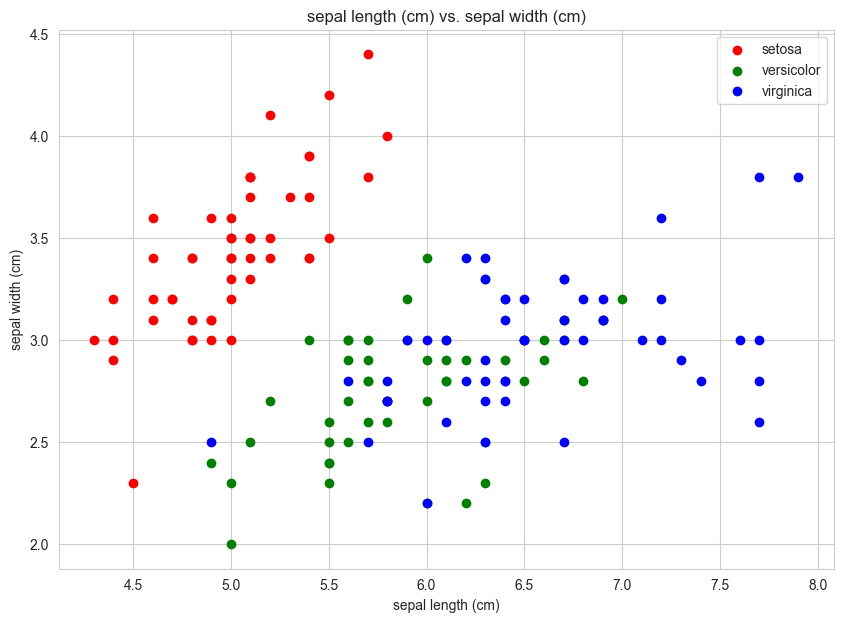

In [11]:
# sepal length와 sepal width에 대한 산점도 생성

colors = ['red', 'green', 'blue']  # 각 클래스별 색상 지정
plt.figure(figsize=(10, 7))
for species_id in unique_species:  # 클래스 0,1,2 반복
    X0 = X[y == species_id]  # y가 i인 데이터만 선택 (logical indexing)
    print(y==species_id)
    f1 = X0[:, 0]  # 0번째 열 → sepal length
    f2 = X0[:, 1]  # 1번째 열 → sepal width

    plt.scatter(
        f1, f2,                     # x축, y축 데이터
        color=colors[species_id],            # 클래스별 색 지정
        label=target_names[species_id]       # legend에 표시할 이름
    )

plt.title('sepal length (cm) vs. sepal width (cm)')  # 그래프 제목
plt.xlabel('sepal length (cm)')  # x축 이름
plt.ylabel('sepal width (cm)')   # y축 이름
plt.legend()  # 범례 표시
plt.show()    # 그래프 출력

### 3.3 상자수염그림

이제 세 품종에 대해 **petal length** (feature index 2)의 분포를 비교해봄.

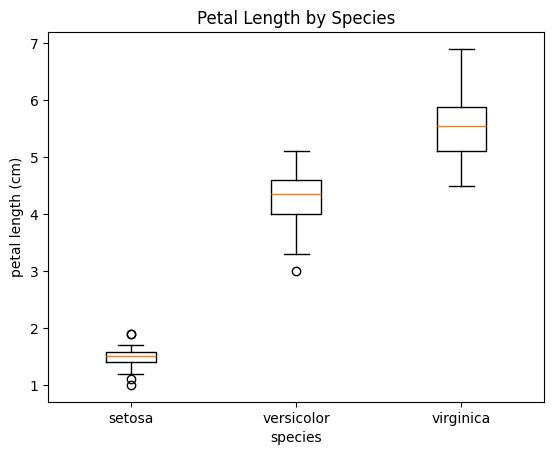

In [21]:
# 품종별 petal length 상자수염그림 생성함

petal_length_index = 2  # iris 데이터에서 2번 열이 petal length (cm) 임
box_data = []           # 품종별 petal length 데이터를 담을 리스트

for species_id in unique_species:  # 각 품종 id(0, 1, 2)에 대해 반복
    # 현재 species_id와 같은 품종의 샘플들만 선택한 뒤,
    # 그 중에서 petal length 열(2번 열)만 추출함
    petal_lengths = X[y == species_id, petal_length_index]

    # 추출한 현재 품종의 petal length 배열을 box_data에 추가함
    box_data.append(petal_lengths)

# box_data를 이용해서 품종별 상자수염그림을 그림
# labels=target_names 를 주면 x축에 setosa, versicolor, virginica 가 표시됨
plt.boxplot(box_data, tick_labels=target_names)

plt.title('Petal Length by Species') # 그래프 제목 설정

plt.xlabel('species') # x축 라벨 설정

plt.ylabel('petal length (cm)') # y축 라벨 설정

plt.show() # 그래프 출력

## 4. 정리

이 노트북에서 수행한 내용은 다음과 같음.

1. `pandas` 없이 `scikit-learn`으로 Iris 데이터셋을 불러옴.
2. NumPy를 사용해 평균, 표준편차, 샘플 수를 계산함.
3. 히스토그램, 산점도, 상자수염그림을 직접 그림.